# 패션 플랫폼 사용자 행동 패턴 분석 — 탐색적 데이터 분석

---

## 분석 개요
정제된 설문 데이터를 바탕으로 표본 신뢰도를 검증하고 응답자 행동 패턴을 탐색한다.

| 항목 | 내용 |
|------|------|
| 분석 대상 | MySQL `survey` 테이블 |
| 응답자 수 | 266명 (논리 모순 3건 제거 후) |
| 10–30대 비율 | 95.1% (253명), 40대 이상 13명 소수 포함 |
| 분석 목적 | 표본 신뢰도 확인, 인구통계·플랫폼 사용 현황 파악 |


---

## 이 노트북의 역할

이 노트북은 전체 프로젝트의 탐색 단계로, 이후 NPS·리텐션·RFM·텍스트 분석에서 다룰 핵심 변수의 분포와 분석 방향을 확인한다.

개별 차이를 확정적으로 검증하기보다, 후속 분석에서 더 깊게 볼 질문을 잡는 데 목적이 있다. 변수 간 관계의 세부 검정과 세그먼트별 해석은 이후 노트북에서 다룬다.


### 해석 기준

- 이 표본은 20대 비중이 높아 전체 패션 플랫폼 시장이 아니라 20대 중심 표본의 사용자 경험으로 해석한다.
- 다중응답 문항은 응답자 비율 기준으로 보며, 합계가 100%를 넘을 수 있다.
- 플랫폼별 비교는 복수 선택 응답이므로 플랫폼 간 독립 표본 비교가 아니다.
- 이 노트북의 관찰은 후속 분석의 출발점이며, 인과관계로 해석하지 않는다.


### 핵심 요약 지표

| 지표 | 값 | 해석 |
|---|---:|---|
| 전체 응답자 | 266명 | 논리 모순 3건 제거 후 분석 기준 |
| 플랫폼 사용자 | 200명 | NPS·채널·불만족 분석 기준 |
| 최근 6개월 내 구매자 | 191명 | 구매 행동·RFM 분석 기준 |
| 20대 비율 | 72.9% | 20대 중심 표본 |
| 월 10만원 미만 지출 | 65.4% | 저·중지출 중심 패션 소비 |
| 무신사 선택 비율 | 62.5% | 이 표본에서 가장 많이 선택된 플랫폼 |
| 최근 3개월 내 구매자 | 84.3% | 구매자 기준 최근 구매 비중 높음 |


In [1]:
import math
import pandas as pd
import numpy as np
from scipy import stats
import plotly.graph_objects as go
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os

In [2]:
load_dotenv()

engine = create_engine(
    f"mysql+mysqlconnector://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}/{os.getenv('DB_NAME')}"
)

df = pd.read_sql('SELECT * FROM survey', engine)

def split_multi_response(series, sep=', '):
    return series.dropna().str.split(sep).explode().str.strip()

def add_pct(count_series, denominator):
    return count_series.div(denominator).mul(100).round(1)


In [3]:
df.head()

,user_id,timestamp,gender,age,content_freq,monthly_spend,uses_platform,platforms,selection_factors,open_purpose,purchase_count,last_purchase,avg_spend,repurchase_reason,dissatisfaction,continue_use,nps,discovery,influence,feedback
0,1,2026-04-25 19:07:24,남성,20대 후반,보통이다,5~10만원,예,"무신사, 자라, 룩핀","가격 / 할인 혜택, 브랜드 및 상품 다양성, 나에게 맞는 스타일 추천","특정 상품을 구매하기 위해, 그냥 구경하기 위해 (윈도우 쇼핑)",3~5번,1~3개월,7~15만원,"배송 또는 상품 품질이 만족스러워서, 원하는 브랜드나 상품이 있어서","사이즈 문제, 배송이 느렸음",계속 사용할 것 같다,7.0,인스타그램 / 틱톡 / 스레드 등 SNS (광고 및 인플루언서 포함),인스타그램 / 틱톡 / 스레드 등 SNS (광고 및 인플루언서 포함),내가 생각했던 내 핏이 아니라서 반품과정이 번거롭다
1,2,2026-04-25 19:08:09,남성,20대 후반,보통이다,10~20만원,예,"무신사, KREAM","브랜드 및 상품 다양성, 앱 사용 편의성 (UI/UX), 나에게 맞는 스타일 추천","특정 상품을 구매하기 위해, 스타일 아이디어를 얻기 위해",3~5번,1개월 이내,3~7만원,"배송 또는 상품 품질이 만족스러워서, 특별한 이유 없이 익숙해서",사이즈 문제,아마 사용할 것 같다,7.0,인스타그램 / 틱톡 / 스레드 등 SNS (광고 및 인플루언서 포함),인스타그램 / 틱톡 / 스레드 등 SNS (광고 및 인플루언서 포함),재고가 없어서 배송이 느린 제품 가끔 존재함
2,3,2026-04-25 19:10:08,남성,20대 초중반,가끔 본다,5만원 미만,예,"무신사, KREAM","가격 / 할인 혜택, 브랜드 및 상품 다양성, 앱 사용 편의성 (UI/UX)","특정 상품을 구매하기 위해, 그냥 구경하기 위해 (윈도우 쇼핑)",1~2번,1~3개월,7~15만원,특별한 이유 없이 익숙해서,불만족 경험 없음,계속 사용할 것 같다,10.0,친구 / 지인 추천,친구 / 지인 추천,None
3,4,2026-04-25 19:18:35,남성,20대 후반,가끔 본다,5만원 미만,예,"무신사, 종합 쇼핑몰","가격 / 할인 혜택, 브랜드 및 상품 다양성, 리뷰 / 후기 신뢰도","스타일 아이디어를 얻기 위해, 할인 또는 특가 확인",1~2번,3~6개월,3~7만원,쿠폰 / 적립금 등 혜택이 좋아서,사이즈 문제,아마 사용할 것 같다,5.0,친구 / 지인 추천,유튜브,"무신사 같은 경우에, 수치 기입하는곳은 없고 키와 몸무게? + 연령대로 사이즈와 추..."
4,5,2026-04-25 19:19:23,남성,20대 초중반,가끔 본다,5~10만원,예,"무신사, 4910","가격 / 할인 혜택, 리뷰 / 후기 신뢰도, 나에게 맞는 스타일 추천","특정 상품을 구매하기 위해, 스타일 아이디어를 얻기 위해",1~2번,1개월 이내,3~7만원,"앱 UI/UX가 편리하고 사용하기 좋아서, 특별한 이유 없이 익숙해서","실제 상품이 사진과 달랐음, 사이즈 문제",계속 사용할 것 같다,9.0,인스타그램 / 틱톡 / 스레드 등 SNS (광고 및 인플루언서 포함),특별히 없음,None


In [4]:
df.shape

(266, 20)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            266 non-null    int64         
 1   timestamp          266 non-null    datetime64[ns]
 2   gender             266 non-null    object        
 3   age                266 non-null    object        
 4   content_freq       266 non-null    object        
 5   monthly_spend      266 non-null    object        
 6   uses_platform      266 non-null    object        
 7   platforms          200 non-null    object        
 8   selection_factors  200 non-null    object        
 9   open_purpose       200 non-null    object        
 10  purchase_count     200 non-null    object        
 11  last_purchase      191 non-null    object        
 12  avg_spend          191 non-null    object        
 13  repurchase_reason  191 non-null    object        
 14  dissatisfa

---

## 표본 신뢰도
분석 전 표본의 통계적 신뢰도와 주요 문항 간 내적 일관성을 먼저 점검한다.


### 표본 대표성
국내 주요 패션 플랫폼 실사용자 통계와 비교해 표본의 인구통계적 대표성을 점검한다.


In [6]:
# 표본 성별·연령대 분포
gender_dist = df['gender'].value_counts(normalize=True).mul(100).round(1)
age_dist = df['age'].value_counts(normalize=True).mul(100).round(1)

print('=== 성별 분포 ===')
print(gender_dist.to_string())
print()
print('=== 연령대 분포 ===')
print(age_dist.sort_index().to_string())
mz_ratio = (df['age'].isin(['10대', '20대 초중반', '20대 후반', '30대'])).sum() / len(df) * 100
print(f'\n10~30대 비율: {mz_ratio:.1f}%')

=== 성별 분포 ===
gender
여성    52.6
남성    47.4

=== 연령대 분포 ===
age
10대         2.6
20대 초중반    37.2
20대 후반     35.7
30대        19.5
40대 이상      4.9

10~30대 비율: 95.1%


> ### 📊 표본 대표성 검토
>
> 국내 패션 앱 실사용자 통계(와이즈앱·아이지에이웍스)와 이 표본을 비교한다.
>
> | 항목 | 업계 통계 | 이 표본 | 평가 |
> |------|----------|--------|------|
> | 20대 비율 | 31-46% (에이블리-지그재그) | **73%** | 과대대표 |
> | 여성 비율 | 53-71% (무신사 53.8%-전체 시장 71%) | **53%** | 유사 수준 |
> | 10–30대 | 주요 응답층 | **95.1%** | 표본 대부분을 차지 |
>
> **💡 해석**
> 응답자의 95.1%가 10–30대이며, 20대 비율(73%)이 실제 패션 앱 사용자(31-46%, 와이즈앱 2025)보다 높고 여성 비율(53%)은 실제(53-71%)와 유사하거나 낮은 수준이다.
> 본 분석의 결과는 전체 패션 플랫폼 사용자보다 **20대 중심 표본의 인식을 더 강하게 반영**하며, 일반화 시 이 점을 고려해야 한다.
>
> **📚 출처**
> - [패션 앱 TOP 3, 20대 비율 30% 넘어 — 한국섬유신문 (와이즈앱, 2025.01-09)](https://www.ktnews.com/news/articleView.html?idxno=141947)
> - [1,624만명의 의류/패션앱 시장 — 매드클럽 (아이지에이웍스, 2024.04)](http://www.madclub.co.kr/news/articleView.html?idxno=4860)
> - [25년 9월 패션 앱 동향 — 와이즈앱](https://www.wiseapp.co.kr/insight/detail/857/2025-fashion-app-generation-mau-revisit-time-sessions)


### 표본오차


In [7]:
n = len(df)
p = (df["uses_platform"] == "예").sum() / n  # 플랫폼 사용자 비율
z_95 = 1.96
z_90 = 1.645
me_95 = z_95 * math.sqrt(p * (1 - p) / n)
me_90 = z_90 * math.sqrt(p * (1 - p) / n)

print(f"표본 크기         : {n}명")
print(f"플랫폼 사용자 비율 : {p * 100:.1f}%")
print(f"표본오차 (95%)    : ±{me_95 * 100:.1f}%")
print(f"표본오차 (90%)    : ±{me_90 * 100:.1f}%")

표본 크기         : 266명
플랫폼 사용자 비율 : 75.2%
표본오차 (95%)    : ±5.2%
표본오차 (90%)    : ±4.4%


> 응답자의 95.1%(253명)가 10–30대이며, 40대 이상(13명)이 소수 포함되어 있다.
> 분석은 20대 중심 표본의 경향으로 해석하되 전체 266명을 대상으로 한다.
>
> 단순 무작위 표본을 가정하면 신뢰수준 95% 기준 표본오차는 약 ±5.2%p 수준이다.
> 다만 본 조사는 편의표본에 가까우므로, 이 값은 모집단 일반화를 보장하는 수치가 아니라 **표본 규모의 정밀도를 가늠하는 참고값**으로 해석한다.


### 내적 일관성
두 문항 간 양의 상관이 확인되면 같은 개념을 일관되게 측정하고 있음을 의미한다.


In [8]:
# NPS ↔ continue_use: 추천 의향과 계속 사용 의향이 같은 방향을 측정하는지 확인
CONTINUE_USE_MAP = {
    '다른 앱으로 바꿀 것 같다': 1,
    '아마 사용하지 않을 것 같다': 2,
    '잘 모르겠다': 3,
    '아마 사용할 것 같다': 4,
    '계속 사용할 것 같다': 5,
}

users = df[df['uses_platform'] == '예'].copy()
users['continue_use_code'] = users['continue_use'].map(CONTINUE_USE_MAP)

corr, pval = stats.spearmanr(
    users['nps'].dropna(),
    users['continue_use_code'].loc[users['nps'].dropna().index]
)
p_str = f'= {pval:.4f}' if pval >= 0.0001 else '< 0.001'
print(f'NPS ↔ continue_use 스피어만 상관: r = {corr:.3f}, p {p_str}')

NPS ↔ continue_use 스피어만 상관: r = 0.400, p < 0.001


In [9]:
# monthly_spend ↔ avg_spend: 월 지출과 구매 객단가가 같은 방향을 측정하는지 확인
MONTHLY_SPEND_MAP = {
    '5만원 미만': 1, '5~10만원': 2, '10~20만원': 3,
    '20~30만원': 4, '30만원 이상': 5,
}
AVG_SPEND_MAP = {
    '3만원 미만': 1, '3~7만원': 2, '7~15만원': 3,
    '15~30만원': 4, '30만원 이상': 5,
}

buyers = df[df['avg_spend'].notna()].copy()
buyers['monthly_code'] = buyers['monthly_spend'].map(MONTHLY_SPEND_MAP)
buyers['avg_code'] = buyers['avg_spend'].map(AVG_SPEND_MAP)

corr2, pval2 = stats.spearmanr(buyers['monthly_code'], buyers['avg_code'])
p_str2 = f'= {pval2:.4f}' if pval2 >= 0.0001 else '< 0.001'
print(f'monthly_spend ↔ avg_spend 스피어만 상관: r = {corr2:.3f}, p {p_str2}')

monthly_spend ↔ avg_spend 스피어만 상관: r = 0.399, p < 0.001


In [10]:
# Q9 ↔ Q10: 구매 횟수 많을수록 최근에 구매했는지 확인 (구매자만)
PURCHASE_COUNT_MAP = {'구매하지 않음': 0, '1~2번': 1, '3~5번': 2, '6번 이상': 3}
LAST_PURCHASE_MAP = {'6개월 이상': 1, '3~6개월': 2, '1~3개월': 3, '1개월 이내': 4}

buyers = df[df['last_purchase'].notna()].copy()
buyers['pc_code'] = buyers['purchase_count'].map(PURCHASE_COUNT_MAP)
buyers['lp_code'] = buyers['last_purchase'].map(LAST_PURCHASE_MAP)

corr3, pval3 = stats.spearmanr(buyers['pc_code'], buyers['lp_code'])
p_str3 = f'= {pval3:.4f}' if pval3 >= 0.0001 else '< 0.001'
print(f'purchase_count ↔ last_purchase 스피어만 상관: r = {corr3:.3f}, p {p_str3}')

purchase_count ↔ last_purchase 스피어만 상관: r = 0.450, p < 0.001


In [11]:
# Q3 ↔ Q9: 콘텐츠 탐색 많이 할수록 구매도 많은지 확인 (플랫폼 사용자)
CONTENT_FREQ_MAP = {
    '전혀 찾아보지 않는다': 1, '가끔 본다': 2, '보통이다': 3,
    '자주 본다': 4, '매우 자주 본다': 5,
}

users_cf = df[df['uses_platform'] == '예'].copy()
users_cf['cf_code'] = users_cf['content_freq'].map(CONTENT_FREQ_MAP)
users_cf['pc_code'] = users_cf['purchase_count'].map(PURCHASE_COUNT_MAP)

corr4, pval4 = stats.spearmanr(users_cf['cf_code'], users_cf['pc_code'])
p_str4 = f'= {pval4:.4f}' if pval4 >= 0.0001 else '< 0.001'
print(f'content_freq ↔ purchase_count 스피어만 상관: r = {corr4:.3f}, p {p_str4}')

content_freq ↔ purchase_count 스피어만 상관: r = 0.470, p < 0.001


In [12]:
# Q3 ↔ Q4: 패션 콘텐츠 탐색 활발할수록 월 지출도 높은지 확인
MONTHLY_SPEND_MAP2 = {'5만원 미만':1,'5~10만원':2,'10~20만원':3,'20~30만원':4,'30만원 이상':5}

df_cf = df[['content_freq','monthly_spend']].dropna().copy()
df_cf['cf_code'] = df_cf['content_freq'].map(CONTENT_FREQ_MAP)
df_cf['ms_code'] = df_cf['monthly_spend'].map(MONTHLY_SPEND_MAP2)

corr5, pval5 = stats.spearmanr(df_cf['cf_code'], df_cf['ms_code'])
p_str5 = f'= {pval5:.4f}' if pval5 >= 0.0001 else '< 0.001'
print(f'content_freq ↔ monthly_spend 스피어만 상관: r = {corr5:.3f}, p {p_str5}')

content_freq ↔ monthly_spend 스피어만 상관: r = 0.543, p < 0.001


> ### 📊 데이터 점검 결과
>
> 주요 순서형 변수들이 예상 방향으로 연결되는지 확인했다. 이 단계의 목적은 가설을 확정하기보다, 이후 NPS·리텐션·RFM 분석에 사용할 변수들이 최소한의 일관성을 갖는지 점검하는 것이다.
>
> **점검 결과**
>
> | 변수 쌍 | 질문 | n | ρ | p-value | 해석 |
> |---------|------|---:|---:|---------|------|
> | NPS ↔ 계속 사용 의향 | Q15 ↔ Q14 | 200 | 0.400 | <0.001 | 추천 의향↑ → 계속 사용 의향↑ |
> | 월 지출 ↔ 구매 객단가 | Q4 ↔ Q11 | 191 | 0.399 | <0.001 | 월 지출↑ → 구매 1회 금액↑ |
> | 구매 횟수 ↔ 최근 구매 시점 | Q9 ↔ Q10 | 191 | 0.450 | <0.001 | 구매 많을수록 → 최근에 구매 |
> | 콘텐츠 탐색 ↔ 구매 횟수 | Q3 ↔ Q9 | 200 | 0.470 | <0.001 | 탐색 활발↑ → 구매 횟수↑ |
> | 콘텐츠 탐색 ↔ 월 지출 | Q3 ↔ Q4 | 266 | 0.543 | <0.001 | 탐색 활발↑ → 월 지출↑ |
>
> **💡 핵심 요약**
> 5개 변수 쌍 모두 예상 방향의 양의 관계를 보였다. 효과 크기는 약함-보통 수준이므로 강한 예측 관계로 단정하지 않고, 후속 분석에서 방향성을 확인하는 참고 근거로 사용한다.


---

## 인구통계
응답자의 성별·연령대 분포를 살펴본다.


### 성별 분포


In [13]:
gender_counts = (
    df['gender']
    .value_counts()
    .reset_index()
    .rename(columns={'gender':'성별','count':'응답자 수'})
)
gender_counts

,성별,응답자 수
0,여성,140
1,남성,126


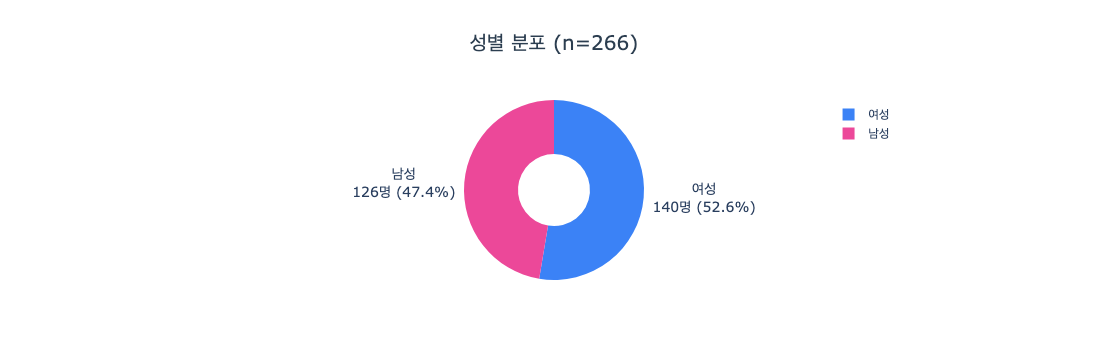

In [14]:
fig = go.Figure(go.Pie(
    labels=gender_counts['성별'],
    values=gender_counts['응답자 수'],
    marker_colors=['#3B82F6', '#EC4899'],
    texttemplate='%{label}<br>%{value}명 (%{percent})',
    textfont=dict(size=14),
    hole=0.4,
))
fig.update_layout(
    title=dict(text=f'성별 분포 (n={len(df)})', x=0.5, xanchor='center', font=dict(size=20, color='#2c3e50')),
    paper_bgcolor='white',
)
fig.show()

### 연령대 분포


In [15]:
AGE_ORDER = ['10대', '20대 초중반', '20대 후반', '30대', '40대 이상']
age_counts = (
    df['age']
    .value_counts()
    .reindex(AGE_ORDER)
    .reset_index()
    .rename(columns={'age':'연령대','count':'응답자 수'})
)
age_counts

,연령대,응답자 수
0,10대,7
1,20대 초중반,99
2,20대 후반,95
3,30대,52
4,40대 이상,13


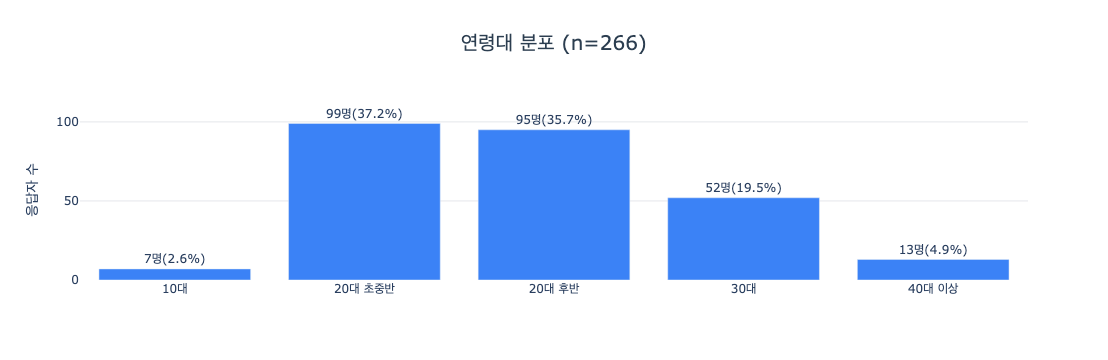

In [16]:
fig = go.Figure(go.Bar(
    x=age_counts['연령대'],
    y=age_counts['응답자 수'],
    marker_color='#3B82F6',
    text=[f"{cnt}명({cnt / len(df) * 100:.1f}%)" for cnt in age_counts['응답자 수']],
    textposition='outside',
))
fig.update_layout(
    title=dict(text=f'연령대 분포 (n={len(df)})', x=0.5, xanchor='center', font=dict(size=20, color='#2c3e50')),
    plot_bgcolor='white', paper_bgcolor='white',
    yaxis=dict(gridcolor='#e5e7eb', title='응답자 수', range=[0, age_counts['응답자 수'].max() * 1.15]),
    xaxis=dict(title=''),
)
fig.show()

### 성별 × 연령대


In [17]:
gender_age = (
    df.groupby(['age', 'gender'])
    .size()
    .unstack(fill_value=0)
    .reindex(AGE_ORDER)
)
gender_age

gender,남성,여성
age,,
10대,5,2
20대 초중반,38,61
20대 후반,53,42
30대,26,26
40대 이상,4,9


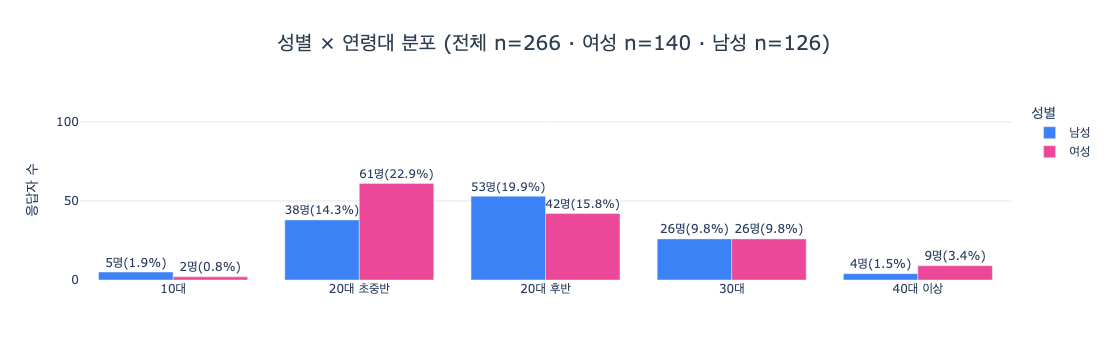

In [18]:
female_total = int(gender_age['여성'].sum()) if '여성' in gender_age.columns else 0
male_total = int(gender_age['남성'].sum()) if '남성' in gender_age.columns else 0
gender_age_total = int(gender_age.values.sum())

fig = go.Figure()
for gender, color in [('남성','#3B82F6'), ('여성','#EC4899')]:
    if gender in gender_age.columns:
        fig.add_trace(go.Bar(
            name=gender,
            x=gender_age.index,
            y=gender_age[gender],
            marker_color=color,
            text=[f"{int(cnt)}명({cnt / gender_age_total * 100:.1f}%)" for cnt in gender_age[gender]],
            textposition='outside',
        ))
fig.update_layout(
    title=dict(text=f'성별 × 연령대 분포 (전체 n={gender_age_total} · 여성 n={female_total} · 남성 n={male_total})',
                x=0.5, xanchor='center', font=dict(size=20, color='#2c3e50')),
    barmode='group',
    plot_bgcolor='white', paper_bgcolor='white',
    yaxis=dict(gridcolor='#e5e7eb', title='응답자 수', range=[0, age_counts['응답자 수'].max() * 1.15]),
    xaxis=dict(title=''),
    legend=dict(title='성별'),
)
fig.show()

---

## 패션 소비 성향
응답자의 패션 콘텐츠 소비 빈도와 월 평균 지출 분포를 살펴본다.


### 성별 × 패션 콘텐츠 탐색 빈도


In [19]:
# 성별 × 패션 콘텐츠 탐색 빈도: 해당 성별 전체 분모
CONTENT_ORDER = ['전혀 찾아보지 않는다', '가끔 본다', '보통이다', '자주 본다', '매우 자주 본다']
female_total = (df['gender'] == '여성').sum()
male_total = (df['gender'] == '남성').sum()

gc_freq = (df.groupby(['gender', 'content_freq'], observed=False).size()
             .reset_index(name='응답자 수'))
gc_freq['비율'] = gc_freq.apply(
    lambda r: r['응답자 수'] / (female_total if r['gender'] == '여성' else male_total) * 100,
    axis=1
).round(1)

gc_pivot = (gc_freq.pivot(index='content_freq', columns='gender', values='비율')
            .reindex(CONTENT_ORDER))
gc_n = (gc_freq.pivot(index='content_freq', columns='gender', values='응답자 수')
        .reindex(CONTENT_ORDER))
gc_pivot

gender,남성,여성
content_freq,,
전혀 찾아보지 않는다,15.1,5.0
가끔 본다,42.9,30.7
보통이다,25.4,15.0
자주 본다,13.5,40.0
매우 자주 본다,3.2,9.3


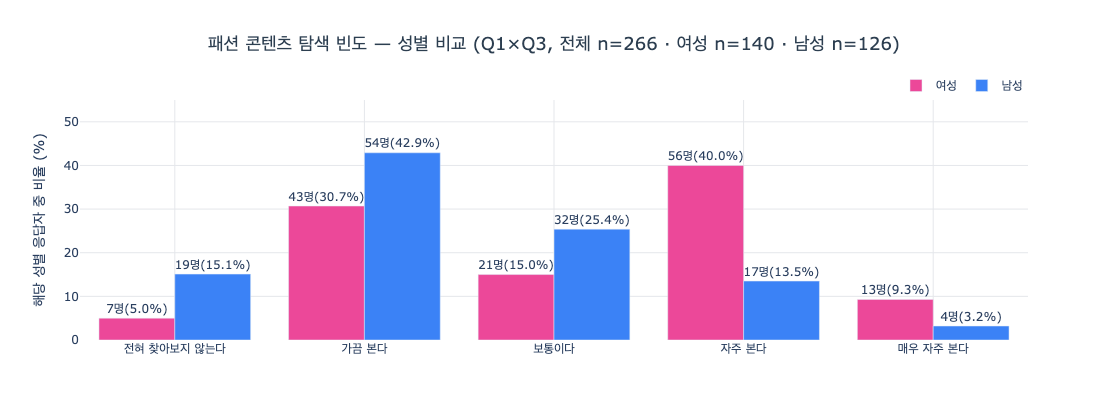

In [20]:
fig = go.Figure()
fig.add_trace(go.Bar(name='여성', x=CONTENT_ORDER, y=gc_pivot['여성'],
    marker_color='#EC4899',
    text=[f'{int(n)}명({p:.1f}%)' for n, p in zip(gc_n['여성'], gc_pivot['여성'])],
    textposition='outside'))
fig.add_trace(go.Bar(name='남성', x=CONTENT_ORDER, y=gc_pivot['남성'],
    marker_color='#3B82F6',
    text=[f'{int(n)}명({p:.1f}%)' for n, p in zip(gc_n['남성'], gc_pivot['남성'])],
    textposition='outside'))
fig.update_layout(
    title=dict(text=f'패션 콘텐츠 탐색 빈도 — 성별 비교 (Q1×Q3, 전체 n={len(df)} · 여성 n={female_total} · 남성 n={male_total})',
               x=0.5, xanchor='center', font=dict(size=18, color='#2c3e50')),
    barmode='group', plot_bgcolor='white', paper_bgcolor='white',
    xaxis=dict(gridcolor='#e5e7eb', title=''),
    yaxis=dict(gridcolor='#e5e7eb', title='해당 성별 응답자 중 비율 (%)', range=[0, 55]),
    height=420,
    legend=dict(orientation='h', yanchor='bottom', y=1.0, xanchor='right', x=1))
fig.show()


### 성별 × 월 지출


In [21]:
SPEND_ORDER = ['5만원 미만', '5~10만원', '10~20만원', '20~30만원', '30만원 이상']
gender_spend = (
    df.groupby(['monthly_spend', 'gender'])
    .size()
    .unstack(fill_value=0)
    .reindex(SPEND_ORDER)
)
gender_spend

gender,남성,여성
monthly_spend,,
5만원 미만,53,40
5~10만원,35,46
10~20만원,23,30
20~30만원,9,19
30만원 이상,6,5


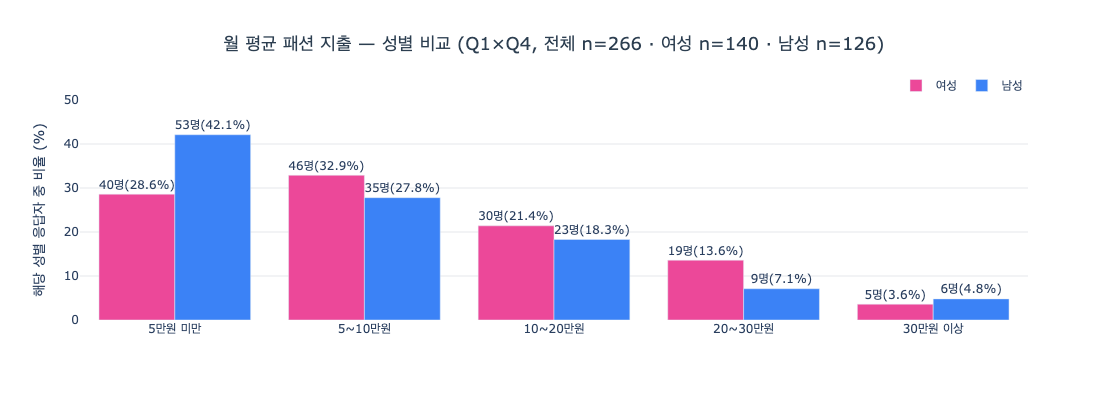

In [22]:
female_total = (df['gender'] == '여성').sum()
male_total = (df['gender'] == '남성').sum()

gs_pct = gender_spend.copy().astype(float)
if '여성' in gs_pct.columns: gs_pct['여성'] = gender_spend['여성'] / female_total * 100
if '남성' in gs_pct.columns: gs_pct['남성'] = gender_spend['남성'] / male_total * 100
gs_pct = gs_pct.round(1)

fig = go.Figure()
for gender, color in [('여성','#EC4899'), ('남성','#3B82F6')]:
    if gender in gender_spend.columns:
        fig.add_trace(go.Bar(
            name=gender, x=gender_spend.index, y=gs_pct[gender],
            marker_color=color,
            text=[f'{int(n)}명({p:.1f}%)' for n, p in zip(gender_spend[gender], gs_pct[gender])],
            textposition='outside'))
fig.update_layout(
    title=dict(text=f'월 평균 패션 지출 — 성별 비교 (Q1×Q4, 전체 n={len(df)} · 여성 n={female_total} · 남성 n={male_total})',
               x=0.5, xanchor='center', font=dict(size=18, color='#2c3e50')),
    barmode='group', plot_bgcolor='white', paper_bgcolor='white',
    yaxis=dict(gridcolor='#e5e7eb', title='해당 성별 응답자 중 비율 (%)',
               range=[0, max(gs_pct.values.max() * 1.15, 50)]),
    xaxis=dict(title=''),
    height=400,
    legend=dict(orientation='h', yanchor='bottom', y=1.0, xanchor='right', x=1))
fig.show()


---

## 플랫폼 사용 현황
패션 플랫폼 이용 여부, 주요 사용 플랫폼, 선택 요소, 오픈 목적을 살펴본다.


### 플랫폼 사용 여부


In [23]:
platform_use = (
    df['uses_platform']
    .value_counts()
    .reset_index()
    .rename(columns={'uses_platform':'사용 여부','count':'응답자 수'})
)
platform_use

,사용 여부,응답자 수
0,예,200
1,아니오,66


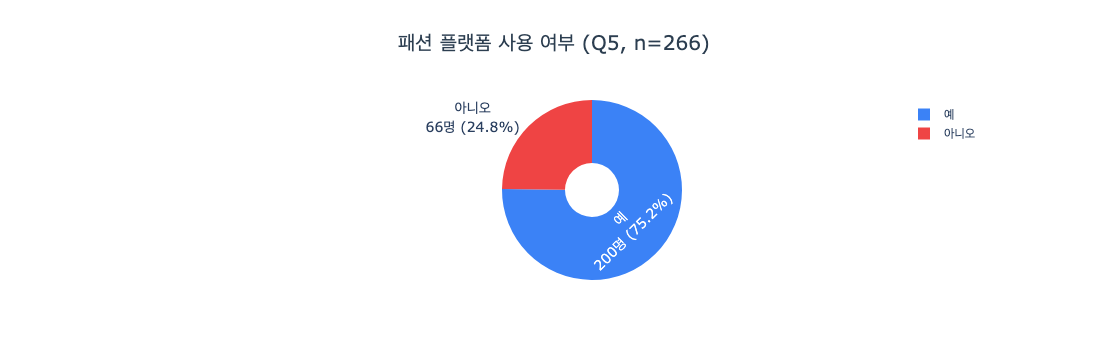

In [24]:
fig = go.Figure(go.Pie(
    labels=platform_use['사용 여부'],
    values=platform_use['응답자 수'],
    marker_colors=['#3B82F6', '#EF4444'],
    texttemplate='%{label}<br>%{value}명 (%{percent})',
    textfont=dict(size=14),
    hole=0.3,
))
fig.update_layout(
    title=dict(text=f'패션 플랫폼 사용 여부 (Q5, n={len(df)})', x=0.5, xanchor='center', font=dict(size=20, color='#2c3e50')),
    paper_bgcolor='white',
)
fig.show()

### 주요 플랫폼 선택률


In [25]:
platform_user_n = (df['uses_platform'] == '예').sum()
platform_exploded = (
    split_multi_response(df['platforms'])
    .value_counts()
    .reset_index()
    .rename(columns={'platforms': '플랫폼', 'count': '언급 수'})
)
platform_exploded['선택률'] = add_pct(platform_exploded['언급 수'], platform_user_n)
platform_exploded


,플랫폼,언급 수,선택률
0,무신사,125,62.5
1,에이블리,63,31.5
2,지그재그,50,25.0
3,종합 쇼핑몰,47,23.5
4,KREAM,35,17.5
5,29CM,21,10.5
6,기타,10,5.0
7,4910,7,3.5
8,룩핀,2,1.0
9,W컨셉,2,1.0


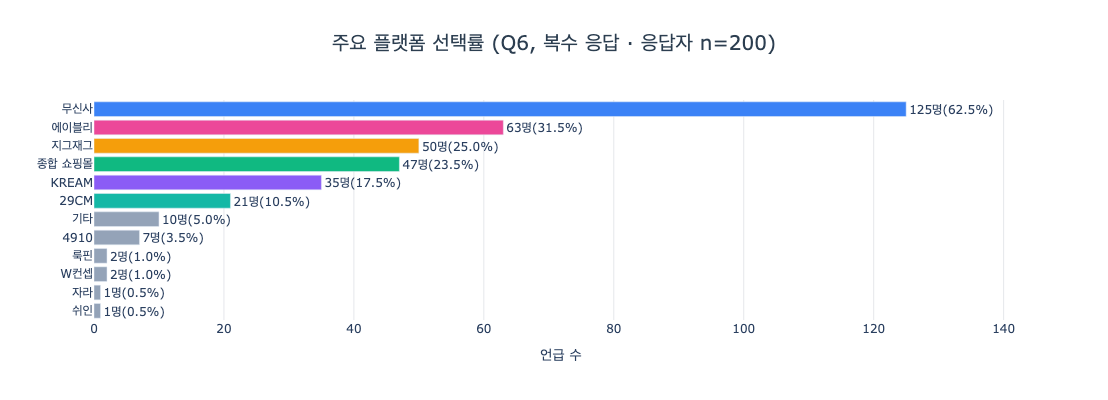

In [26]:
PLATFORM_COLORS = {
    '무신사':'#3B82F6', '에이블리':'#EC4899', '지그재그':'#F59E0B',
    '종합 쇼핑몰':'#10B981', 'KREAM':'#8B5CF6', '29CM':'#14B8A6', '기타':'#94A3B8',
}
colors = [PLATFORM_COLORS.get(p, '#94A3B8') for p in platform_exploded['플랫폼']]

fig = go.Figure(go.Bar(
    x=platform_exploded['언급 수'],
    y=platform_exploded['플랫폼'],
    orientation='h',
    marker_color=colors,
    text=[f"{cnt}명({pct:.1f}%)" for cnt, pct in zip(platform_exploded['언급 수'], platform_exploded['선택률'])],
    textposition='outside',
))
fig.update_layout(
    title=dict(text=f'주요 플랫폼 선택률 (Q6, 복수 응답 · 응답자 n={platform_user_n})', x=0.5, xanchor='center', font=dict(size=20, color='#2c3e50')),
    plot_bgcolor='white', paper_bgcolor='white',
    xaxis=dict(gridcolor='#e5e7eb', title='언급 수', range=[0, platform_exploded['언급 수'].max() * 1.15]),
    yaxis=dict(title='', autorange='reversed'),
    height=400,
)
fig.show()


### 성별 × 플랫폼 선택률


In [27]:
# 성별 × 플랫폼 선택률: 해당 성별 플랫폼 사용자 분모로 정규화
TOP_PLATFORMS = ['무신사', '에이블리', '지그재그', '종합 쇼핑몰', 'KREAM', '29CM']

users_pf = df[df['uses_platform'] == '예'].copy()
female_n = (users_pf['gender'] == '여성').sum()
male_n = (users_pf['gender'] == '남성').sum()

gender_platform_long = (
    users_pf
    .assign(platform=users_pf['platforms'].str.split(', '))
    .explode('platform')
    .assign(platform=lambda x: x['platform'].str.strip())
)

gender_platform = (
    gender_platform_long
    .groupby(['gender', 'platform']).size()
    .reset_index(name='언급 수')
)
gender_platform['비율'] = gender_platform.apply(
    lambda r: r['언급 수'] / (female_n if r['gender'] == '여성' else male_n) * 100,
    axis=1
).round(1)

gp_top = (gender_platform[gender_platform['platform'].isin(TOP_PLATFORMS)]
          .pivot(index='platform', columns='gender', values='비율').reindex(TOP_PLATFORMS))
gp_top_n = (gender_platform[gender_platform['platform'].isin(TOP_PLATFORMS)]
            .pivot(index='platform', columns='gender', values='언급 수').reindex(TOP_PLATFORMS))
gp_top

gender,남성,여성
platform,,
무신사,82.3,49.6
에이블리,6.3,47.9
지그재그,3.8,38.8
종합 쇼핑몰,24.1,23.1
KREAM,34.2,6.6
29CM,6.3,13.2


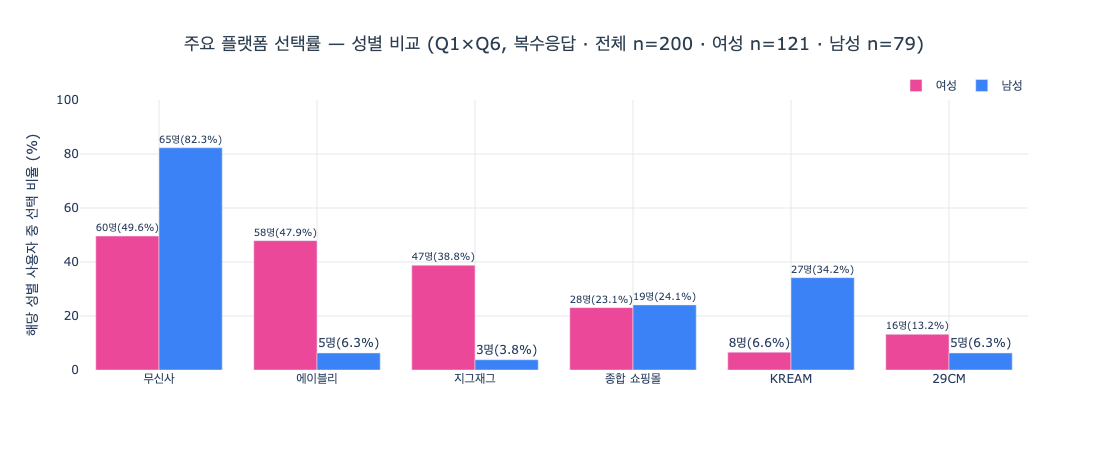

In [28]:
fig = go.Figure()
fig.add_trace(go.Bar(name='여성', x=TOP_PLATFORMS, y=gp_top['여성'],
    marker_color='#EC4899',
    text=[f'{int(n)}명({p:.1f}%)' for n, p in zip(gp_top_n['여성'], gp_top['여성'])],
    textposition='outside'))
fig.add_trace(go.Bar(name='남성', x=TOP_PLATFORMS, y=gp_top['남성'],
    marker_color='#3B82F6',
    text=[f'{int(n)}명({p:.1f}%)' for n, p in zip(gp_top_n['남성'], gp_top['남성'])],
    textposition='outside'))
fig.update_layout(
    title=dict(text=f'주요 플랫폼 선택률 — 성별 비교 (Q1×Q6, 복수응답 · 전체 n={female_n + male_n} · 여성 n={female_n} · 남성 n={male_n})',
               x=0.5, xanchor='center', font=dict(size=18, color='#2c3e50')),
    barmode='group', plot_bgcolor='white', paper_bgcolor='white',
    xaxis=dict(gridcolor='#e5e7eb', title=''),
    yaxis=dict(gridcolor='#e5e7eb', title='해당 성별 사용자 중 선택 비율 (%)', range=[0, 100]),
    height=450,
    legend=dict(orientation='h', yanchor='bottom', y=1.0, xanchor='right', x=1))
fig.show()

### 플랫폼 선택 요소


In [29]:
factors_exploded = (
    df['selection_factors'].dropna()
    .str.split(', ')
    .explode()
    .str.strip()
    .value_counts()
    .reset_index()
    .rename(columns={'selection_factors':'선택 요소','count':'언급 수'})
)
factors_exploded

,선택 요소,언급 수
0,가격 / 할인 혜택,169
1,브랜드 및 상품 다양성,112
2,리뷰 / 후기 신뢰도,88
3,앱 사용 편의성 (UI/UX),59
4,나에게 맞는 스타일 추천,50
5,배송 속도 및 편리성,21
6,적립금 / 멤버십 혜택,20


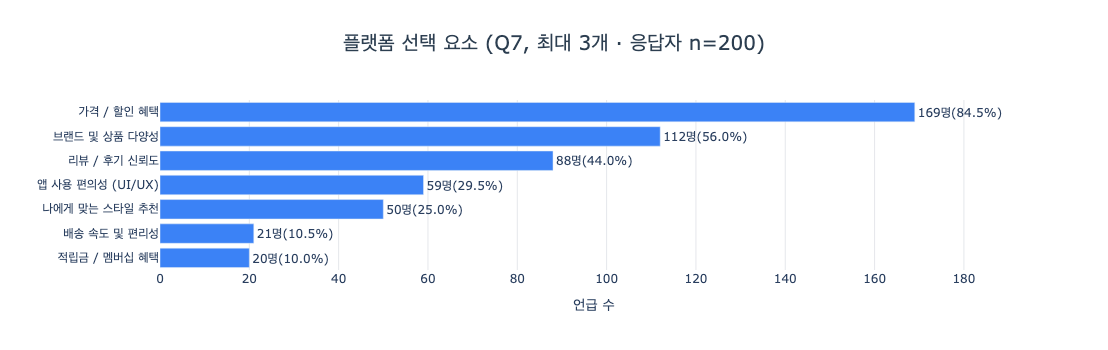

In [30]:
selection_factor_base_n = df['selection_factors'].notna().sum()

fig = go.Figure(go.Bar(
    x=factors_exploded['언급 수'],
    y=factors_exploded['선택 요소'],
    orientation='h',
    marker_color='#3B82F6',
    text=[f"{cnt}명({cnt / selection_factor_base_n * 100:.1f}%)" for cnt in factors_exploded['언급 수']],
    textposition='outside',
))
fig.update_layout(
    title=dict(text=f'플랫폼 선택 요소 (Q7, 최대 3개 · 응답자 n={selection_factor_base_n})', x=0.5, xanchor='center', font=dict(size=20, color='#2c3e50')),
    plot_bgcolor='white', paper_bgcolor='white',
    xaxis=dict(gridcolor='#e5e7eb', title='언급 수', range=[0, factors_exploded['언급 수'].max() * 1.15]),
    yaxis=dict(title='', autorange='reversed'),
    height=350,
)
fig.show()

### 플랫폼 오픈 목적


In [31]:
purpose_exploded = (
    df['open_purpose'].dropna()
    .str.split(', ')
    .explode()
    .str.strip()
    .value_counts()
    .reset_index()
    .rename(columns={'open_purpose':'오픈 목적','count':'언급 수'})
)
purpose_exploded

,오픈 목적,언급 수
0,특정 상품을 구매하기 위해,125
1,그냥 구경하기 위해 (윈도우 쇼핑),115
2,스타일 아이디어를 얻기 위해,57
3,할인 또는 특가 확인,55
4,특정 브랜드 신상품 확인,12


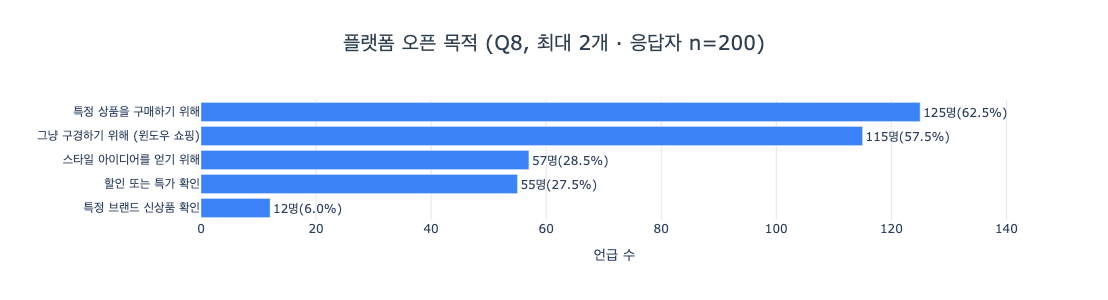

In [32]:
open_purpose_base_n = df['open_purpose'].notna().sum()

fig = go.Figure(go.Bar(
    x=purpose_exploded['언급 수'],
    y=purpose_exploded['오픈 목적'],
    orientation='h',
    marker_color='#3B82F6',
    text=[f"{cnt}명({cnt / open_purpose_base_n * 100:.1f}%)" for cnt in purpose_exploded['언급 수']],
    textposition='outside',
))
fig.update_layout(
    title=dict(text=f'플랫폼 오픈 목적 (Q8, 최대 2개 · 응답자 n={open_purpose_base_n})', x=0.5, xanchor='center', font=dict(size=20, color='#2c3e50')),
    plot_bgcolor='white', paper_bgcolor='white',
    xaxis=dict(gridcolor='#e5e7eb', title='언급 수', range=[0, purpose_exploded['언급 수'].max() * 1.15]),
    yaxis=dict(title='', autorange='reversed'),
    height=300,
)
fig.show()

---

## 유입 경로와 구매 영향 채널
Q16은 현재 사용하는 패션 앱을 처음 알게 된 경로, Q17은 최근 6개월 내 구매에 가장 영향을 준 채널이다.
EDA 단계에서는 채널별 분포와 인지-구매 영향의 차이를 가볍게 확인하고, 상세 해석은 `06_channel.ipynb`에서 다룬다.


In [33]:
def channel_group(value):
    if pd.isna(value):
        return np.nan
    value = str(value)
    if '인스타그램' in value or '틱톡' in value or '스레드' in value or 'SNS' in value:
        return 'SNS'
    if '유튜브' in value:
        return '유튜브'
    if '친구' in value or '지인' in value:
        return '친구/지인'
    if '포털' in value or '검색' in value:
        return '검색'
    if '앱스토어' in value or '플레이스토어' in value:
        return '앱스토어/플레이스토어'
    if '앱 내' in value or '푸시' in value or '쿠폰' in value:
        return '앱 내부 추천/알림'
    if '특별히 없음' in value or '기억' in value:
        return '특별히 없음/기억 안남'
    if '광고' in value:
        return '광고/미디어'
    return '기타'

channel_users = df[df['uses_platform'] == '예'].copy()
channel_users['discovery_group'] = channel_users['discovery'].apply(channel_group)
channel_users['influence_group'] = channel_users['influence'].apply(channel_group)

channel_order = [
    'SNS', '유튜브', '친구/지인', '검색', '앱 내부 추천/알림',
    '앱스토어/플레이스토어', '광고/미디어', '특별히 없음/기억 안남', '기타'
]

first_contact = (
    channel_users['discovery_group'].value_counts()
    .reindex(channel_order, fill_value=0)
    .reset_index()
    .rename(columns={'discovery_group': '채널', 'count': '응답자 수'})
)
first_contact['구분'] = '최초 인지'
first_contact['비율'] = add_pct(first_contact['응답자 수'], channel_users['discovery_group'].notna().sum())

purchase_influence = (
    channel_users['influence_group'].value_counts()
    .reindex(channel_order, fill_value=0)
    .reset_index()
    .rename(columns={'influence_group': '채널', 'count': '응답자 수'})
)
purchase_influence['구분'] = '최근 구매 영향'
purchase_influence['비율'] = add_pct(purchase_influence['응답자 수'], channel_users['influence_group'].notna().sum())

channel_compare = pd.concat([first_contact, purchase_influence], ignore_index=True)
channel_compare[channel_compare['응답자 수'] > 0]


,채널,응답자 수,구분,비율
0,SNS,84,최초 인지,42.0
1,유튜브,23,최초 인지,11.5
2,친구/지인,48,최초 인지,24.0
3,검색,37,최초 인지,18.5
5,앱스토어/플레이스토어,3,최초 인지,1.5
6,광고/미디어,3,최초 인지,1.5
7,특별히 없음/기억 안남,2,최초 인지,1.0
9,SNS,71,최근 구매 영향,35.5
10,유튜브,49,최근 구매 영향,24.5
11,친구/지인,17,최근 구매 영향,8.5


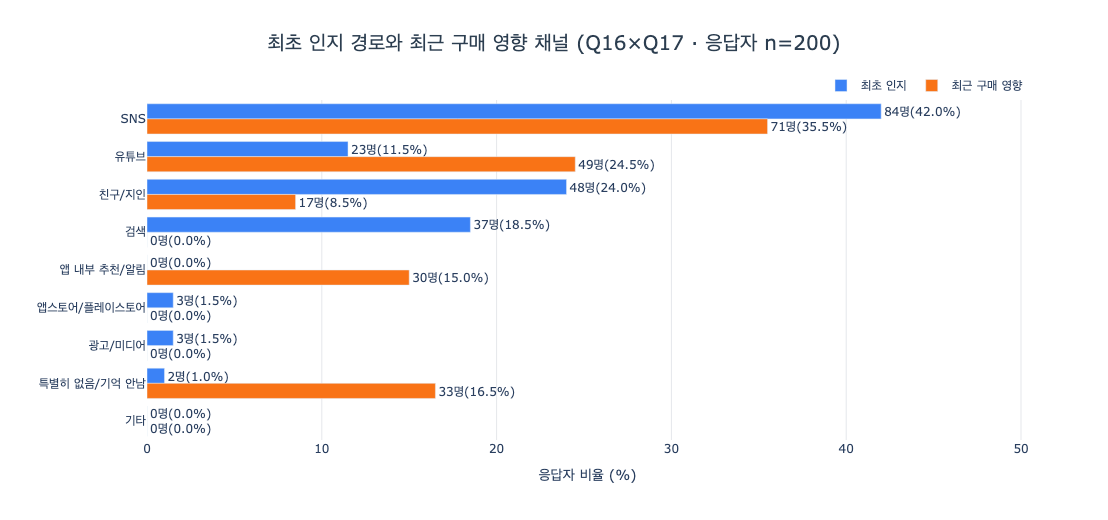

In [34]:
fig = go.Figure()
for label, color in [('최초 인지', '#3B82F6'), ('최근 구매 영향', '#F97316')]:
    subset = channel_compare[channel_compare['구분'] == label]
    fig.add_trace(go.Bar(
        name=label,
        x=subset['비율'],
        y=subset['채널'],
        orientation='h',
        marker_color=color,
        text=[f"{int(n)}명({p:.1f}%)" for n, p in zip(subset['응답자 수'], subset['비율'])],
        textposition='outside',
    ))

fig.update_layout(
    title=dict(text=f'최초 인지 경로와 최근 구매 영향 채널 (Q16×Q17 · 응답자 n={len(channel_users)})',
               x=0.5, xanchor='center', font=dict(size=20, color='#2c3e50')),
    barmode='group',
    plot_bgcolor='white', paper_bgcolor='white',
    xaxis=dict(gridcolor='#e5e7eb', title='응답자 비율 (%)', range=[0, channel_compare['비율'].max() * 1.2]),
    yaxis=dict(title='', autorange='reversed'),
    legend=dict(orientation='h', yanchor='bottom', y=1.0, xanchor='right', x=1),
    height=520,
)
fig.show()

> **채널 해석 메모**
>
> 최초 인지는 SNS, 지인 추천, 검색처럼 외부 접점의 역할이 크고, 최근 구매 영향은 SNS와 유튜브, 앱 내부 추천/알림의 역할을 함께 확인할 필요가 있다.
> 따라서 채널 분석은 단순 유입 경로 순위보다 **인지 채널과 구매 설득 채널의 역할 차이**로 해석하는 편이 적절하다.


---

## 플랫폼별 비교
상위 6개 플랫폼 선택 응답자를 기준으로 선택 요소와 불만족 경험을 비교한다.

> ⚠️ 플랫폼별 비교는 해당 플랫폼을 선택한 응답자 기준이며, 복수 응답으로 인해 중복이 존재한다. 독립 표본 비교가 아니므로 차이는 참고용으로 해석한다.
>
> 아래 비교는 단순 언급 수가 아니라 **해당 플랫폼 선택자 수 대비 비율**을 함께 사용한다. 플랫폼별 표본 크기가 다르기 때문에, 비율 기준이 플랫폼 간 비교에 더 적합하다.
>
> | 플랫폼 | 응답자 수 | 비고 |
> |--------|----------|------|
> | 무신사 | 125 | 스트릿·캐주얼 중심 버티컬 커머스 |
> | 에이블리 | 63 | 여성 패션 특화 플랫폼 |
> | 지그재그 | 50 | 여성 패션 특화 플랫폼 |
> | 종합 쇼핑몰 | 47 | 쿠팡·네이버쇼핑 등 종합 커머스 |
> | KREAM | 35 | 한정판·리셀 특화 플랫폼 |
> | 29CM | 21 | 감성·라이프스타일 큐레이션 ⚠️ 소표본 |


### 플랫폼별 주요 선택 요소


In [35]:
platform_long = (
    df[df['uses_platform'] == '예']
    .assign(platform=lambda x: x['platforms'].str.split(', '))
    .explode('platform')
    .assign(platform=lambda x: x['platform'].str.strip())
)
platform_n = platform_long.groupby('platform')['user_id'].nunique()

factor_rows = []
for p in TOP_PLATFORMS:
    p_users = platform_long[platform_long['platform'] == p]
    factors = split_multi_response(p_users['selection_factors']).value_counts()
    for factor, cnt in factors.items():
        factor_rows.append({
            '플랫폼': p,
            '선택 요소': factor,
            '언급 수': cnt,
            '선택률': round(cnt / platform_n[p] * 100, 1),
        })

factor_df = pd.DataFrame(factor_rows)

top_factors = (
    factor_df.groupby('선택 요소')['언급 수']
    .sum()
    .nlargest(7)
    .index
    .tolist()
)

factor_count_pivot = (
    factor_df[factor_df['선택 요소'].isin(top_factors)]
    .pivot(index='선택 요소', columns='플랫폼', values='언급 수')
    .fillna(0)
    .reindex(columns=TOP_PLATFORMS)
)

factor_rate_pivot = (
    factor_df[factor_df['선택 요소'].isin(top_factors)]
    .pivot(index='선택 요소', columns='플랫폼', values='선택률')
    .fillna(0)
    .reindex(columns=TOP_PLATFORMS)
)
factor_rate_pivot


플랫폼,무신사,에이블리,지그재그,종합 쇼핑몰,KREAM,29CM
선택 요소,,,,,,
가격 / 할인 혜택,87.2,90.5,82.0,100.0,68.6,76.2
나에게 맞는 스타일 추천,25.6,23.8,26.0,31.9,31.4,14.3
리뷰 / 후기 신뢰도,44.0,52.4,38.0,51.1,45.7,38.1
배송 속도 및 편리성,9.6,6.3,20.0,6.4,8.6,4.8
브랜드 및 상품 다양성,61.6,46.0,54.0,55.3,71.4,71.4
앱 사용 편의성 (UI/UX),27.2,33.3,26.0,23.4,34.3,33.3
적립금 / 멤버십 혜택,8.8,7.9,16.0,10.6,2.9,14.3


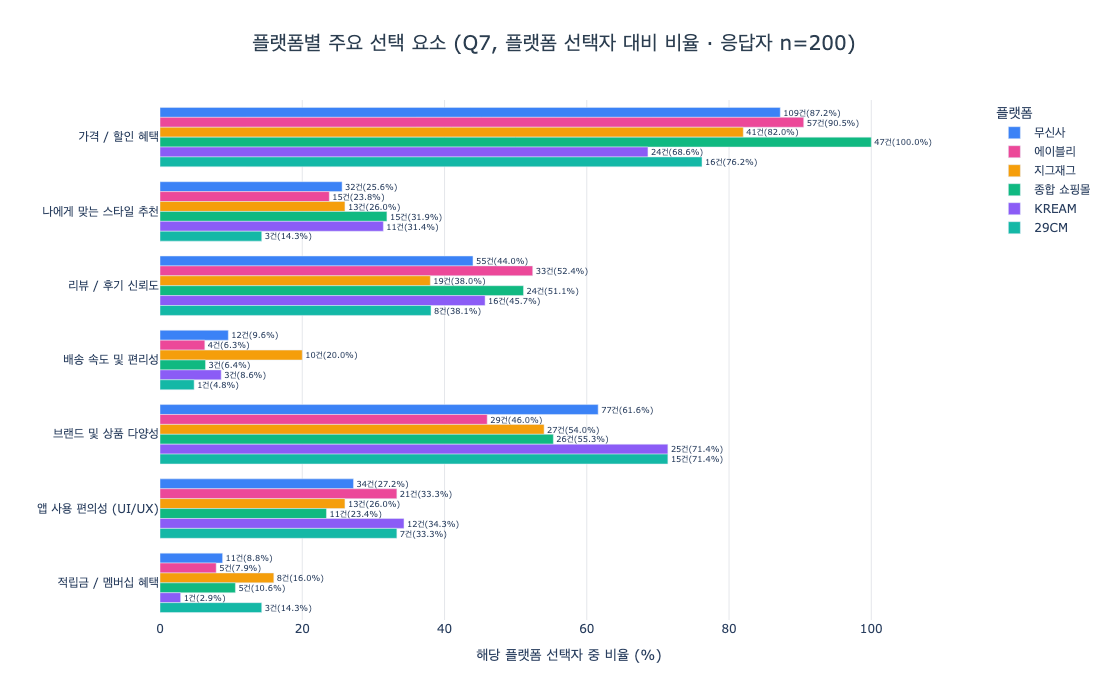

In [36]:
fig = go.Figure()
for p in TOP_PLATFORMS:
    fig.add_trace(go.Bar(
        name=p,
        x=factor_rate_pivot[p],
        y=factor_rate_pivot.index,
        orientation='h',
        marker_color=PLATFORM_COLORS.get(p, '#94A3B8'),
        text=[f"{int(cnt)}건({rate:.1f}%)" for cnt, rate in zip(factor_count_pivot[p], factor_rate_pivot[p])],
        textposition='outside',
    ))
fig.update_layout(
    title=dict(text=f'플랫폼별 주요 선택 요소 (Q7, 플랫폼 선택자 대비 비율 · 응답자 n={platform_user_n})', x=0.5, xanchor='center', font=dict(size=20, color='#2c3e50')),
    barmode='group',
    plot_bgcolor='white', paper_bgcolor='white',
    xaxis=dict(gridcolor='#e5e7eb', title='해당 플랫폼 선택자 중 비율 (%)', range=[0, factor_rate_pivot.values.max() * 1.15]),
    yaxis=dict(title='', autorange='reversed'),
    legend=dict(title='플랫폼'),
    height=700,
)
fig.show()


### 플랫폼별 불만족 경험


In [37]:
EXCLUDE_DIS = {'불만족 경험 없음', '구매 경험 자체가 없음'}

dis_rows = []
for p in TOP_PLATFORMS:
    p_users = platform_long[platform_long['platform'] == p]
    items = split_multi_response(p_users['dissatisfaction'])
    items = items[~items.isin(EXCLUDE_DIS)]
    for item, cnt in items.value_counts().items():
        dis_rows.append({
            '플랫폼': p,
            '불만족 항목': item,
            '언급 수': cnt,
            '선택률': round(cnt / platform_n[p] * 100, 1),
        })

dis_df = pd.DataFrame(dis_rows)

top_dis = (
    dis_df.groupby('불만족 항목')['언급 수']
    .sum()
    .nlargest(5)
    .index
    .tolist()
)

dis_count_pivot = (
    dis_df[dis_df['불만족 항목'].isin(top_dis)]
    .pivot(index='불만족 항목', columns='플랫폼', values='언급 수')
    .fillna(0)
    .reindex(columns=TOP_PLATFORMS)
)

dis_rate_pivot = (
    dis_df[dis_df['불만족 항목'].isin(top_dis)]
    .pivot(index='불만족 항목', columns='플랫폼', values='선택률')
    .fillna(0)
    .reindex(columns=TOP_PLATFORMS)
)
dis_rate_pivot


플랫폼,무신사,에이블리,지그재그,종합 쇼핑몰,KREAM,29CM
불만족 항목,,,,,,
반품 / 교환 과정이 불편했음,20.0,25.4,34.0,19.1,20.0,33.3
배송이 느렸음,27.2,28.6,34.0,6.4,22.9,23.8
사이즈 문제,52.0,58.7,48.0,55.3,42.9,33.3
실제 상품이 사진과 달랐음,44.0,55.6,48.0,48.9,28.6,28.6


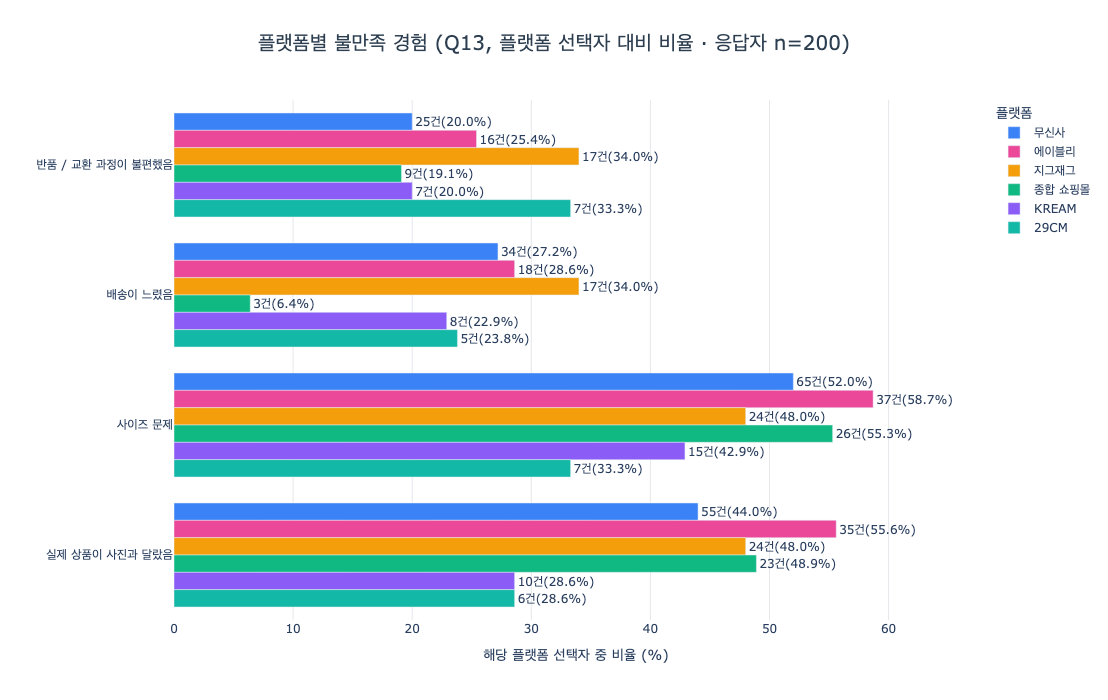

In [38]:
fig = go.Figure()
for p in TOP_PLATFORMS:
    fig.add_trace(go.Bar(
        name=p,
        x=dis_rate_pivot[p],
        y=dis_rate_pivot.index,
        orientation='h',
        marker_color=PLATFORM_COLORS.get(p, '#94A3B8'),
        text=[f"{int(cnt)}건({rate:.1f}%)" for cnt, rate in zip(dis_count_pivot[p], dis_rate_pivot[p])],
        textposition='outside',
    ))
fig.update_layout(
    title=dict(text=f'플랫폼별 불만족 경험 (Q13, 플랫폼 선택자 대비 비율 · 응답자 n={platform_user_n})', x=0.5, xanchor='center', font=dict(size=20, color='#2c3e50')),
    barmode='group',
    plot_bgcolor='white', paper_bgcolor='white',
    xaxis=dict(gridcolor='#e5e7eb', title='해당 플랫폼 선택자 중 비율 (%)', range=[0, dis_rate_pivot.values.max() * 1.15]),
    yaxis=dict(title='', autorange='reversed'),
    legend=dict(title='플랫폼'),
    height=700,
)
fig.show()


---

## 구매 행동
플랫폼 사용자(n=200)의 구매 빈도, 최근 구매 시점, 객단가를 살펴본다.
이 변수들은 이후 세그멘테이션 분석의 입력 변수로 활용된다.


### 구매자 vs 비구매자


In [39]:
users = df[df['uses_platform'] == '예'].copy()

purchase_status = (
    users['purchase_count']
    .map(lambda x: '비구매자' if x == '구매하지 않음' else '구매자')
    .value_counts()
    .reset_index()
    .rename(columns={'purchase_count':'구매 여부','count':'응답자 수'})
)
purchase_status

,구매 여부,응답자 수
0,구매자,191
1,비구매자,9


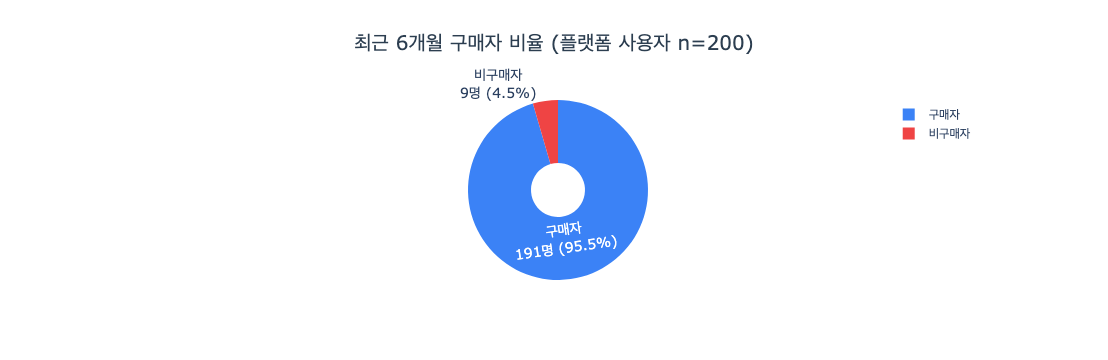

In [40]:
fig = go.Figure(go.Pie(
    labels=purchase_status['구매 여부'],
    values=purchase_status['응답자 수'],
    marker_colors=['#3B82F6', '#EF4444'],
    texttemplate='%{label}<br>%{value}명 (%{percent})',
    textfont=dict(size=14),
    hole=0.3,
))
fig.update_layout(
    title=dict(text=f'최근 6개월 구매자 비율 (플랫폼 사용자 n={len(users)})', x=0.5, xanchor='center', font=dict(size=20, color='#2c3e50')),
    paper_bgcolor='white',
)
fig.show()

### 성별 × 구매 횟수


In [41]:
# 성별 × 구매 횟수: 해당 성별 구매자 분모로 정규화
buyers = users[users['purchase_count'] != '구매하지 않음']
PURCHASE_F = ['1~2번', '3~5번', '6번 이상']

gf_count = (buyers.groupby(['gender', 'purchase_count'], observed=False).size()
                   .reset_index(name='응답자 수'))
gf_count['비율'] = gf_count.apply(
    lambda r: r['응답자 수'] / ((buyers['gender'] == r['gender']).sum()) * 100,
    axis=1
).round(1)

gf_count_pivot = (gf_count[gf_count['purchase_count'].isin(PURCHASE_F)]
                  .pivot(index='purchase_count', columns='gender', values='비율').reindex(PURCHASE_F))
gf_count_n = (gf_count[gf_count['purchase_count'].isin(PURCHASE_F)]
              .pivot(index='purchase_count', columns='gender', values='응답자 수').reindex(PURCHASE_F))
gf_count_pivot

gender,남성,여성
purchase_count,,
1~2번,42.5,25.4
3~5번,37.0,37.3
6번 이상,20.5,37.3


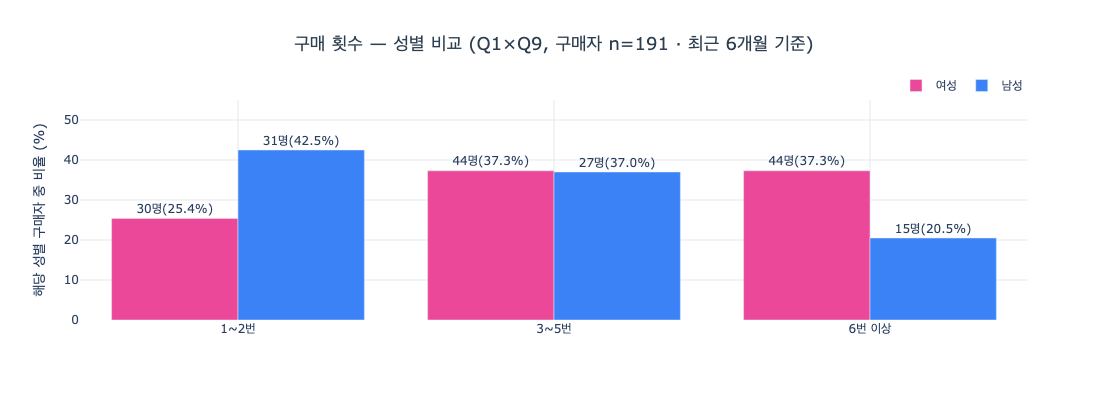

In [42]:
fig = go.Figure()
fig.add_trace(go.Bar(name='여성', x=PURCHASE_F, y=gf_count_pivot['여성'],
    marker_color='#EC4899',
    text=[f'{int(n)}명({p:.1f}%)' for n, p in zip(gf_count_n['여성'], gf_count_pivot['여성'])],
    textposition='outside'))
fig.add_trace(go.Bar(name='남성', x=PURCHASE_F, y=gf_count_pivot['남성'],
    marker_color='#3B82F6',
    text=[f'{int(n)}명({p:.1f}%)' for n, p in zip(gf_count_n['남성'], gf_count_pivot['남성'])],
    textposition='outside'))
fig.update_layout(
    title=dict(text=f'구매 횟수 — 성별 비교 (Q1×Q9, 구매자 n={len(buyers)} · 최근 6개월 기준)',
               x=0.5, xanchor='center', font=dict(size=18, color='#2c3e50')),
    barmode='group', plot_bgcolor='white', paper_bgcolor='white',
    xaxis=dict(gridcolor='#e5e7eb', title=''),
    yaxis=dict(gridcolor='#e5e7eb', title='해당 성별 구매자 중 비율 (%)', range=[0, 55]),
    height=400,
    legend=dict(orientation='h', yanchor='bottom', y=1.0, xanchor='right', x=1))
fig.show()


### 성별 × 최근 구매 시점


In [43]:
# 성별 × 최근 구매 시점
LAST_ORDER = ['6개월 이상', '3~6개월', '1~3개월', '1개월 이내']

gr_last = (buyers.groupby(['gender', 'last_purchase'], observed=False).size()
                  .reset_index(name='응답자 수'))
gr_last['비율'] = gr_last.apply(
    lambda r: r['응답자 수'] / ((buyers['gender'] == r['gender']).sum()) * 100,
    axis=1
).round(1)

gr_last_pivot = (gr_last.pivot(index='last_purchase', columns='gender', values='비율')
                 .reindex(LAST_ORDER))
gr_last_n = (gr_last.pivot(index='last_purchase', columns='gender', values='응답자 수')
             .reindex(LAST_ORDER))
gr_last_pivot

gender,남성,여성
last_purchase,,
6개월 이상,4.1,2.5
3~6개월,15.1,11.0
1~3개월,41.1,26.3
1개월 이내,39.7,60.2


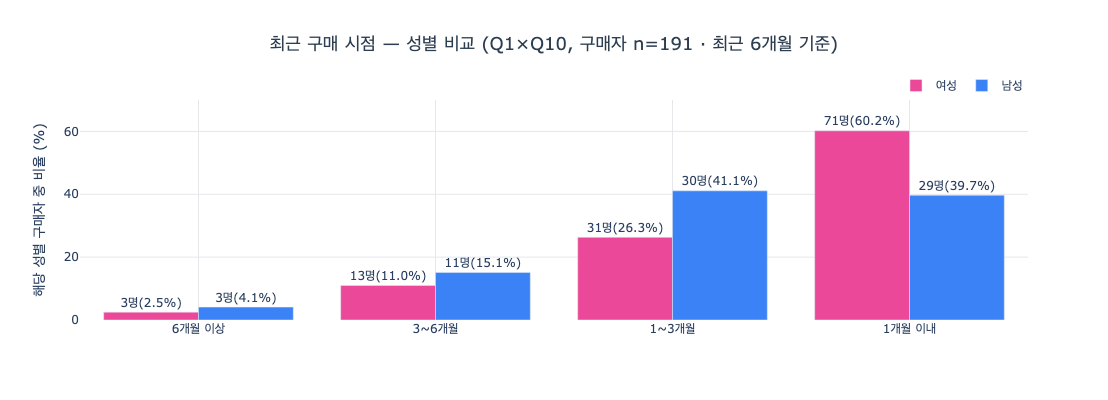

In [44]:
fig = go.Figure()
fig.add_trace(go.Bar(name='여성', x=LAST_ORDER, y=gr_last_pivot['여성'],
    marker_color='#EC4899',
    text=[f'{int(n)}명({p:.1f}%)' for n, p in zip(gr_last_n['여성'], gr_last_pivot['여성'])],
    textposition='outside'))
fig.add_trace(go.Bar(name='남성', x=LAST_ORDER, y=gr_last_pivot['남성'],
    marker_color='#3B82F6',
    text=[f'{int(n)}명({p:.1f}%)' for n, p in zip(gr_last_n['남성'], gr_last_pivot['남성'])],
    textposition='outside'))
fig.update_layout(
    title=dict(text=f'최근 구매 시점 — 성별 비교 (Q1×Q10, 구매자 n={len(buyers)} · 최근 6개월 기준)',
               x=0.5, xanchor='center', font=dict(size=18, color='#2c3e50')),
    barmode='group', plot_bgcolor='white', paper_bgcolor='white',
    xaxis=dict(gridcolor='#e5e7eb', title=''),
    yaxis=dict(gridcolor='#e5e7eb', title='해당 성별 구매자 중 비율 (%)', range=[0, 70]),
    height=400,
    legend=dict(orientation='h', yanchor='bottom', y=1.0, xanchor='right', x=1))
fig.show()


### 성별 × 구매 객단가


In [45]:
# 성별 × 구매 객단가
AVG_ORDER = ['3만원 미만', '3~7만원', '7~15만원', '15~30만원', '30만원 이상']

gm_avg = (buyers.groupby(['gender', 'avg_spend'], observed=False).size()
                 .reset_index(name='응답자 수'))
gm_avg['비율'] = gm_avg.apply(
    lambda r: r['응답자 수'] / ((buyers['gender'] == r['gender']).sum()) * 100,
    axis=1
).round(1)

gm_avg_pivot = (gm_avg.pivot(index='avg_spend', columns='gender', values='비율')
                .reindex(AVG_ORDER))
gm_avg_n = (gm_avg.pivot(index='avg_spend', columns='gender', values='응답자 수')
            .reindex(AVG_ORDER))
gm_avg_pivot

gender,남성,여성
avg_spend,,
3만원 미만,5.5,10.2
3~7만원,38.4,50.0
7~15만원,45.2,27.1
15~30만원,9.6,11.9
30만원 이상,1.4,0.8


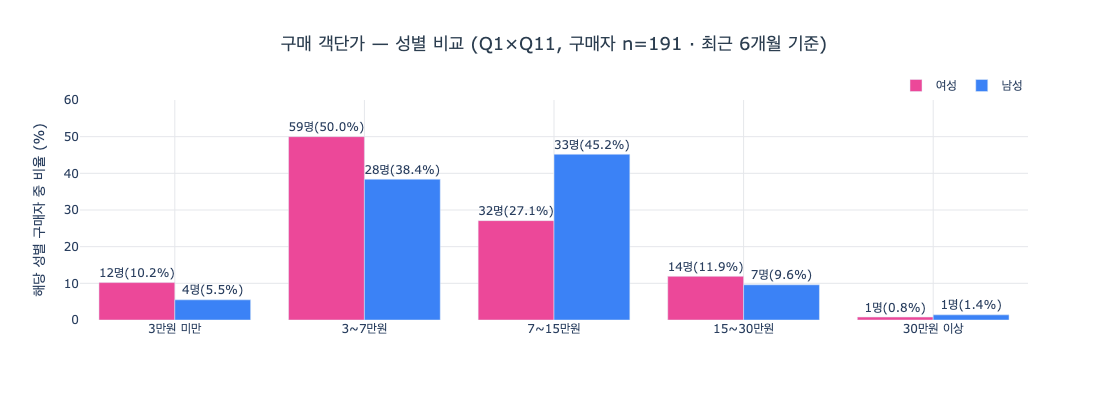

In [46]:
fig = go.Figure()
fig.add_trace(go.Bar(name='여성', x=AVG_ORDER, y=gm_avg_pivot['여성'],
    marker_color='#EC4899',
    text=[f'{int(n)}명({p:.1f}%)' for n, p in zip(gm_avg_n['여성'], gm_avg_pivot['여성'])],
    textposition='outside'))
fig.add_trace(go.Bar(name='남성', x=AVG_ORDER, y=gm_avg_pivot['남성'],
    marker_color='#3B82F6',
    text=[f'{int(n)}명({p:.1f}%)' for n, p in zip(gm_avg_n['남성'], gm_avg_pivot['남성'])],
    textposition='outside'))
fig.update_layout(
    title=dict(text=f'구매 객단가 — 성별 비교 (Q1×Q11, 구매자 n={len(buyers)} · 최근 6개월 기준)',
               x=0.5, xanchor='center', font=dict(size=18, color='#2c3e50')),
    barmode='group', plot_bgcolor='white', paper_bgcolor='white',
    xaxis=dict(gridcolor='#e5e7eb', title=''),
    yaxis=dict(gridcolor='#e5e7eb', title='해당 성별 구매자 중 비율 (%)', range=[0, 60]),
    height=400,
    legend=dict(orientation='h', yanchor='bottom', y=1.0, xanchor='right', x=1))
fig.show()


### 재구매 이유


In [47]:
repurchase_exploded = (
    buyers['repurchase_reason'].dropna()
    .str.split(', ')
    .explode()
    .str.strip()
    .value_counts()
    .reset_index()
    .rename(columns={'repurchase_reason':'재구매 이유','count':'언급 수'})
)
repurchase_exploded

,재구매 이유,언급 수
0,쿠폰 / 적립금 등 혜택이 좋아서,83
1,배송 또는 상품 품질이 만족스러워서,67
2,원하는 브랜드나 상품이 있어서,67
3,특별한 이유 없이 익숙해서,59
4,앱 UI/UX가 편리하고 사용하기 좋아서,38


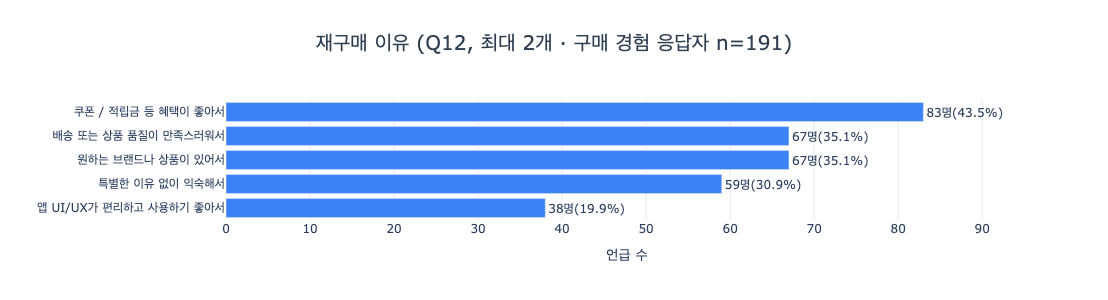

In [48]:
repurchase_base_n = buyers['repurchase_reason'].notna().sum()

fig = go.Figure(go.Bar(
    x=repurchase_exploded['언급 수'],
    y=repurchase_exploded['재구매 이유'],
    orientation='h',
    marker_color='#3B82F6',
    text=[f"{cnt}명({cnt / repurchase_base_n * 100:.1f}%)" for cnt in repurchase_exploded['언급 수']],
    textposition='outside',
))
fig.update_layout(
    title=dict(text=f'재구매 이유 (Q12, 최대 2개 · 구매 경험 응답자 n={repurchase_base_n})', x=0.5, xanchor='center', font=dict(size=20, color='#2c3e50')),
    plot_bgcolor='white', paper_bgcolor='white',
    xaxis=dict(gridcolor='#e5e7eb', title='언급 수', range=[0, repurchase_exploded['언급 수'].max() * 1.15]),
    yaxis=dict(title='', autorange='reversed'),
    height=300,
)
fig.show()

---

## EDA 요약 및 후속 분석 방향

이 EDA는 최종 결론을 내리기보다, 이후 분석에서 검증할 주요 방향을 확인하는 단계다. 아래 관찰은 후속 NPS, 리텐션, RFM, 텍스트 분석의 출발점으로 사용한다.

### 🔎 핵심 관찰

| 관찰 | 의미 |
|---|---|
| 표본은 20대 중심이며, 성별에 따라 콘텐츠 탐색 적극성이 다르다 | 결과 해석 시 20대 중심 표본이라는 한계를 함께 고려해야 함 |
| 플랫폼 선택 기준은 가격/혜택 중심이다 | 재구매와 만족이 혜택 의존인지, 상품/경험 가치와 연결되는지 추가 확인 필요 |
| 플랫폼 사용자는 대부분 최근 6개월 내 구매 경험이 있다 | 구매 행동 기반 리텐션·세그먼트 분석을 적용할 수 있음 |
| 인지 채널과 구매 영향 채널은 역할이 다를 수 있다 | 유입 경로와 구매 설득 채널을 분리해서 볼 필요가 있음 |
| 사이즈/사진-실물 차이 등 공통 UX 불만이 반복된다 | 자유응답 텍스트 분석에서 UX 병목을 더 구체화할 필요가 있음 |

### ➡️ 후속 분석 질문

| EDA 관찰 | 후속 질문 | 연결 노트북 |
|---|---|---|
| 재구매 이유에서 쿠폰/혜택 비중이 높음 | 혜택 기반 재구매가 NPS 세그먼트별로 다르게 나타나는가? | `03_nps.ipynb` |
| 구매자는 많지만 추천 의향은 낮을 수 있음 | 추천 의향은 실제 구매 행동과 연결되는가? | `04_retention_and_behavior.ipynb` |
| 구매 빈도·최근 구매·객단가 변수가 존재함 | 행동 기준으로 사용자 우선순위를 나눌 수 있는가? | `05_segmentation.ipynb` |
| 최초 인지와 최근 구매 영향 채널의 구성이 다름 | 어떤 채널이 인지와 구매 전환에서 각각 강한가? | `06_channel.ipynb` |
| 플랫폼 공통 불만으로 사이즈/사진 문제가 반복됨 | 자유응답에서도 같은 UX 병목이 나타나는가? | `07_text_analysis.ipynb` |


---

## 📌 상세 관찰 메모

아래 내용은 EDA에서 확인한 방향성이다. 최종 결론보다는, 후속 NPS·리텐션·RFM·텍스트 분석에서 더 깊게 볼 질문으로 연결한다.

---

### ① 표본 특성 — 20대 중심 표본과 탐색 적극성

- 20대 초중반(37.2%) + 20대 후반(35.7%) = **72.9%** 로, 이 표본은 20대 사용자 경험을 강하게 반영한다.
- 패션 콘텐츠를 "자주 본다" 이상으로 응답한 적극 탐색층은 **33.8%(90명)** 수준이다.
- 적극 탐색층은 여성에서 더 높게 나타나, 이후 구매 행동·NPS 해석 시 성별 차이는 보조 관찰로 함께 고려한다.

**후속 연결**: 표본 편향과 탐색 적극성은 `03_nps.ipynb`, `04_retention_and_behavior.ipynb`에서 추천 의향·구매 행동을 해석할 때 참고 기준으로 사용한다.

---

### ② 선택 요인 — 가격/혜택 중심

- 플랫폼 선택 요소에서 **가격/할인 혜택**이 가장 많이 언급되었다.
- 이 표본에서는 무신사 선택 비중이 가장 높았고, 주요 플랫폼 전반에서 가격/혜택이 공통 선택 요인으로 나타났다.
- 재구매 이유에서도 쿠폰/적립금 혜택이 가장 많이 언급되어, 재구매가 상품 가치보다 프로모션에 의존할 가능성을 확인했다.

**후속 연결**: 혜택 기반 재구매가 추천 의향과 어떻게 연결되는지는 `03_nps.ipynb`에서 NPS 세그먼트별로 확인한다.

---

### ③ 구매 행동 — 최근 구매 비중 높음

- 플랫폼 사용자 200명 중 최근 6개월 내 구매자는 **191명(95.5%)**이다.
- 구매자 중 최근 3개월 내 구매 비중은 **84.3%**로, 실제 구매 행동을 기준으로 리텐션 상태를 나눌 수 있는 표본 구조다.
- 구매 빈도, 최근 구매 시점, 객단가 변수가 모두 존재하므로 이후 행동 기반 세그먼트 분석의 입력 변수로 활용 가능하다.

**후속 연결**: 구매 행동과 추천/사용 의향의 연결은 `04_retention_and_behavior.ipynb`, 행동 기반 우선순위 분류는 `05_segmentation.ipynb`에서 다룬다.

---

### ④ 채널 — 인지와 구매 영향의 역할 차이

- 최초 인지는 SNS, 지인 추천, 검색 등 외부 접점에서 주로 발생한다.
- 최근 구매 영향은 SNS뿐 아니라 유튜브, 앱 내부 추천/알림 등 구매 직전 설득 채널도 함께 작동할 가능성이 있다.
- EDA 단계에서는 방향성만 확인하고, 채널별 구매 행동 차이는 별도 노트북에서 분석한다.

**후속 연결**: 채널별 인지·구매 영향 차이는 `06_channel.ipynb`에서 더 구체적으로 다룬다.

---

### ⑤ UX 불만 — 사이즈/핏과 정보 신뢰성

- 플랫폼별 불만족 경험에서 사이즈 문제와 상품 사진-실물 불일치가 반복적으로 나타났다.
- 이는 특정 플랫폼만의 문제가 아니라 온라인 패션 구매에서 반복되는 공통 UX 병목으로 볼 수 있다.
- EDA 단계에서는 방향성만 확인하고, 자유응답 분석에서 실제 사용자의 표현을 통해 더 구체화한다.

**후속 연결**: 사이즈/핏, 리뷰, 사진 신뢰도 문제는 `07_text_analysis.ipynb`에서 자유응답 텍스트로 보완 분석한다.
